In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../outputs/tableau_data/churn_scored.csv')

print(df.shape)
print(df.columns.tolist())
print(df[['monthly_revenue','churn_prob','risk_tier']].describe())

(7043, 28)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'event', 'survival_time', 'signup_channel', 'monthly_revenue', 'support_tickets', 'churn_prob', 'risk_tier']
       monthly_revenue   churn_prob
count      7043.000000  7043.000000
mean         64.732732     0.355177
std          30.177096     0.366954
min          13.470000     0.000501
25%          35.475000     0.029497
50%          70.570000     0.180663
75%          90.055000     0.701759
max         122.750000     0.999378


In [2]:
# Average remaining survival time from our KM model
# Month-to-month median was 35 months
# We'll use a conservative 24 months as expected remaining tenure baseline

df['expected_remaining_months'] = (
    (1 - df['churn_prob']) * 24
).round(1)

# LTV = monthly revenue × expected remaining months
df['ltv_estimate'] = (
    df['monthly_revenue'] * df['expected_remaining_months']
).round(2)

# Revenue at risk = monthly revenue × churn probability
df['revenue_at_risk'] = (
    df['monthly_revenue'] * df['churn_prob']
).round(2)

print("LTV by risk tier:")
print(df.groupby('risk_tier')[['ltv_estimate',
      'revenue_at_risk','monthly_revenue']].mean().round(2))

LTV by risk tier:
           ltv_estimate  revenue_at_risk  monthly_revenue
risk_tier                                                
High             157.64            68.37            74.94
Low             1252.80             6.32            58.53
Medium           815.06            42.36            76.32


In [3]:
# Total revenue at risk
high_risk = df[df['risk_tier'] == 'High']
medium_risk = df[df['risk_tier'] == 'Medium']

print("=== FINANCIAL IMPACT SUMMARY ===\n")
print(f"High risk customers: {len(high_risk)}")
print(f"Total monthly revenue at risk: ${high_risk['revenue_at_risk'].sum():,.0f}")
print(f"Total LTV at risk: ${high_risk['ltv_estimate'].sum():,.0f}")
print(f"\nMedium risk customers: {len(medium_risk)}")
print(f"Total monthly revenue at risk: ${medium_risk['revenue_at_risk'].sum():,.0f}")
print(f"Total LTV at risk: ${medium_risk['ltv_estimate'].sum():,.0f}")

total_at_risk = (high_risk['revenue_at_risk'].sum() + 
                 medium_risk['revenue_at_risk'].sum())
print(f"\nCombined monthly revenue at risk: ${total_at_risk:,.0f}")
print(f"Annualised revenue at risk: ${total_at_risk*12:,.0f}")

=== FINANCIAL IMPACT SUMMARY ===

High risk customers: 1767
Total monthly revenue at risk: $120,806
Total LTV at risk: $278,549

Medium risk customers: 827
Total monthly revenue at risk: $35,032
Total LTV at risk: $674,052

Combined monthly revenue at risk: $155,838
Annualised revenue at risk: $1,870,061


In [4]:
print("=== RETENTION CAMPAIGN ROI ===\n")

# Assumptions
intervention_cost_per_customer = 20  # $20 discount or outreach cost
retention_success_rate = 0.30        # 30% of interventions succeed

high_risk_count = len(high_risk)
total_intervention_cost = high_risk_count * intervention_cost_per_customer
customers_saved = int(high_risk_count * retention_success_rate)
ltv_saved = high_risk['ltv_estimate'].sum() * retention_success_rate
net_roi = ltv_saved - total_intervention_cost

print(f"High risk customers targeted: {high_risk_count}")
print(f"Intervention cost per customer: ${intervention_cost_per_customer}")
print(f"Total intervention cost: ${total_intervention_cost:,.0f}")
print(f"\nAssuming 30% retention success rate:")
print(f"Customers saved: {customers_saved}")
print(f"LTV saved: ${ltv_saved:,.0f}")
print(f"Net ROI: ${net_roi:,.0f}")
print(f"Return on every $1 spent: ${net_roi/total_intervention_cost:.1f}")

=== RETENTION CAMPAIGN ROI ===

High risk customers targeted: 1767
Intervention cost per customer: $20
Total intervention cost: $35,340

Assuming 30% retention success rate:
Customers saved: 530
LTV saved: $83,565
Net ROI: $48,225
Return on every $1 spent: $1.4


In [5]:
print("=== LTV BY ACQUISITION CHANNEL ===\n")
channel_ltv = df.groupby('signup_channel').agg(
    customers=('customerID','count'),
    avg_ltv=('ltv_estimate','mean'),
    avg_churn_prob=('churn_prob','mean'),
    avg_monthly_revenue=('monthly_revenue','mean'),
    high_risk_count=('risk_tier', lambda x: (x=='High').sum())
).round(2)

channel_ltv['high_risk_pct'] = (
    channel_ltv['high_risk_count'] / 
    channel_ltv['customers'] * 100).round(1)

print(channel_ltv.sort_values('avg_ltv', ascending=False))

=== LTV BY ACQUISITION CHANNEL ===

                customers  avg_ltv  avg_churn_prob  avg_monthly_revenue  \
signup_channel                                                            
referral             1730   946.10            0.34                64.77   
organic              2500   930.96            0.37                65.57   
paid_search          2118   915.46            0.36                64.07   
social                695   896.72            0.35                63.64   

                high_risk_count  high_risk_pct  
signup_channel                                  
referral                    406           23.5  
organic                     647           25.9  
paid_search                 532           25.1  
social                      182           26.2  


C:\Users\jagra\AppData\Local\Temp\ipykernel_24528\1008410202.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ltv_by_tier.index, y=ltv_by_tier.values,
C:\Users\jagra\AppData\Local\Temp\ipykernel_24528\1008410202.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_at_risk.index, y=revenue_at_risk.values,
C:\Users\jagra\AppData\Local\Temp\ipykernel_24528\1008410202.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_ltv_plot.index, y=channel_ltv_plot.values,


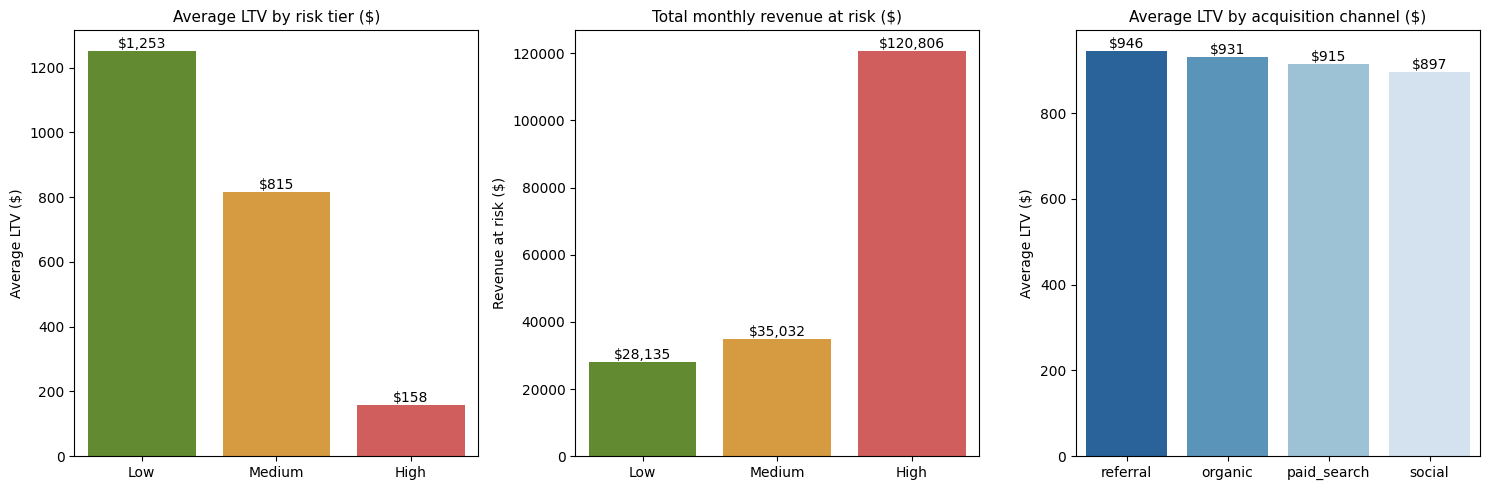

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — LTV by risk tier
risk_order = ['Low', 'Medium', 'High']
ltv_by_tier = df.groupby('risk_tier')['ltv_estimate'].mean().reindex(risk_order)

sns.barplot(x=ltv_by_tier.index, y=ltv_by_tier.values,
            ax=axes[0], palette=['#639922','#EF9F27','#E24B4A'])
axes[0].set_title('Average LTV by risk tier ($)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Average LTV ($)')
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

# Chart 2 — Monthly revenue at risk by tier
revenue_at_risk = df.groupby('risk_tier')['revenue_at_risk'].sum().reindex(risk_order)
sns.barplot(x=revenue_at_risk.index, y=revenue_at_risk.values,
            ax=axes[1], palette=['#639922','#EF9F27','#E24B4A'])
axes[1].set_title('Total monthly revenue at risk ($)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue at risk ($)')
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

# Chart 3 — LTV by acquisition channel
channel_ltv_plot = df.groupby('signup_channel')['ltv_estimate'].mean().sort_values(ascending=False)
sns.barplot(x=channel_ltv_plot.index, y=channel_ltv_plot.values,
            ax=axes[2], palette='Blues_r')
axes[2].set_title('Average LTV by acquisition channel ($)', fontsize=11)
axes[2].set_xlabel('')
axes[2].set_ylabel('Average LTV ($)')
for p in axes[2].patches:
    axes[2].annotate(f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/ltv_financial_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df.to_csv('../outputs/tableau_data/churn_scored.csv', index=False)

print("=== FINAL PROJECT SUMMARY ===\n")
print(f"Total customers analysed: {len(df):,}")
print(f"Overall churn rate: {df['event'].mean()*100:.1f}%")
print(f"High risk customers: {(df['risk_tier']=='High').sum():,}")
print(f"Annualised revenue at risk: ${df['revenue_at_risk'].sum()*12:,.0f}")
print(f"Net ROI from retention campaign: $48,225")
print(f"Model ROC-AUC: 0.940")
print(f"\nCharts saved: {5} files in outputs/charts/")
print(f"Tableau data saved: outputs/tableau_data/churn_scored.csv")

=== FINAL PROJECT SUMMARY ===

Total customers analysed: 7,043
Overall churn rate: 26.5%
High risk customers: 1,767
Annualised revenue at risk: $2,207,678
Net ROI from retention campaign: $48,225
Model ROC-AUC: 0.940

Charts saved: 5 files in outputs/charts/
Tableau data saved: outputs/tableau_data/churn_scored.csv
